In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load dataset from Task B
df = pd.read_csv('sp500_clustered_metrics.csv')
df.head()

,Ticker,Avg_Daily_Return,Beta,Annual_Volatility,Cluster_Agglom,Label_Agglom,Cluster_KMeans,Label_KMeans
0,A,0.000175,0.799134,0.262364,1,Defensive / Low-Risk,1,Defensive / Low-Risk
1,AAPL,0.001100,1.004510,0.211885,1,Defensive / Low-Risk,1,Defensive / Low-Risk
2,ABBV,0.000680,0.238554,0.216108,1,Defensive / Low-Risk,1,Defensive / Low-Risk
3,ABNB,0.000520,1.504928,0.356680,0,Aggressive Growth,0,Aggressive Growth
4,ABT,0.000184,0.261882,0.179846,1,Defensive / Low-Risk,1,Defensive / Low-Risk


In [ ]:
df.columns

Index(['Ticker', 'Avg_Daily_Return', 'Beta', 'Annual_Volatility',
       'Cluster_Agglom', 'Label_Agglom', 'Cluster_KMeans', 'Label_KMeans'],
      dtype='object')

In [ ]:
df.shape

(496, 8)

In [ ]:
cluster_summary = df.groupby('Label_KMeans')[['Avg_Daily_Return', 'Beta', 'Annual_Volatility']].mean()

print(cluster_summary)

                      Avg_Daily_Return      Beta  Annual_Volatility
Label_KMeans                                                       
Aggressive Growth             0.001631  1.352493           0.358664
Defensive / Low-Risk          0.000442  0.578719           0.226327


In [ ]:
cluster_counts = df['Label_KMeans'].value_counts()

print(cluster_counts)

Label_KMeans
Defensive / Low-Risk    310
Aggressive Growth       186
Name: count, dtype: int64


In [ ]:
df.describe()

,Avg_Daily_Return,Beta,Annual_Volatility,Cluster_Agglom,Cluster_KMeans
count,496.000000,496.000000,496.000000,496.000000,496.000000
mean,0.000888,0.868884,0.275953,0.703629,0.625000
std,0.001135,0.523613,0.108136,0.457118,0.484612
min,-0.002191,-0.253226,0.132127,0.000000,0.000000
25%,0.000198,0.499751,0.206507,0.000000,0.000000
50%,0.000792,0.801386,0.246643,1.000000,1.000000
75%,0.001396,1.138988,0.309077,1.000000,1.000000
max,0.010241,3.258963,1.105148,1.000000,1.000000


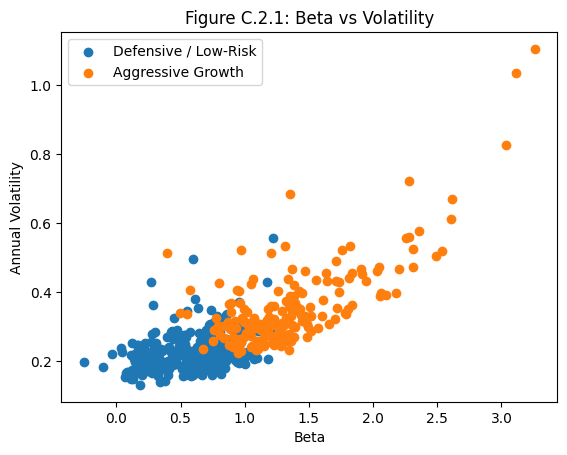

In [ ]:
for label in df['Label_KMeans'].unique():
    subset = df[df['Label_KMeans'] == label]
    plt.scatter(subset['Beta'], subset['Annual_Volatility'], label=label)

plt.xlabel('Beta')
plt.ylabel('Annual Volatility')
plt.title('Figure C.2.1: Beta vs Volatility')
plt.legend()
plt.savefig('beta_vs_volatility.png')
plt.show()

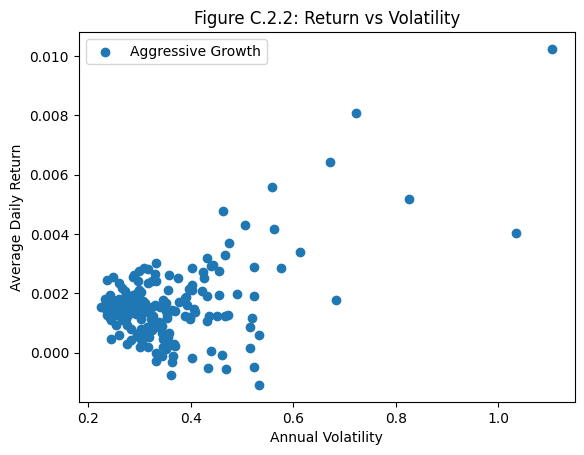

In [ ]:
plt.scatter(subset['Annual_Volatility'], subset['Avg_Daily_Return'], label=label)
plt.xlabel('Annual Volatility')
plt.ylabel('Average Daily Return')
plt.title('Figure C.2.2: Return vs Volatility')
plt.legend()
plt.savefig('return_vs_volatility.png')
plt.show()

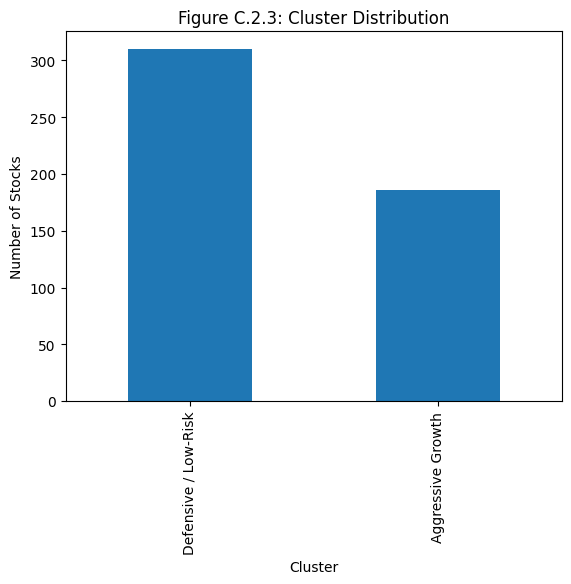

In [ ]:
cluster_counts.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Number of Stocks')
plt.title('Figure C.2.3: Cluster Distribution')
plt.savefig('cluster_distribution.png')
plt.show()

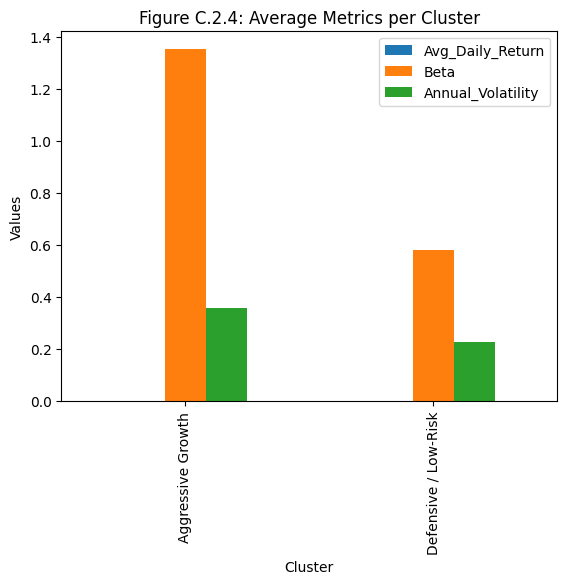

In [ ]:
cluster_summary.plot(kind='bar')

plt.title('Figure C.2.4: Average Metrics per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Values')
plt.savefig('average_metrics_per_cluster.png')
plt.show()

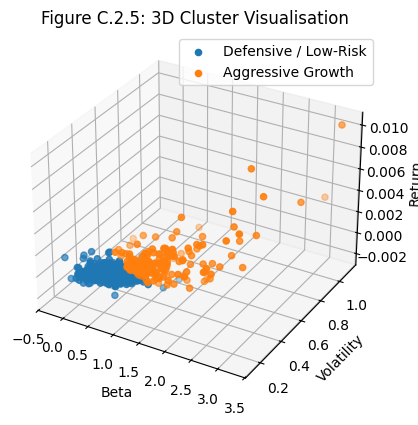

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label in df['Label_KMeans'].unique():
    subset = df[df['Label_KMeans'] == label]
    ax.scatter(
        subset['Beta'],
        subset['Annual_Volatility'],
        subset['Avg_Daily_Return'],
        label=label
    )

ax.set_xlabel('Beta')
ax.set_ylabel('Volatility')
ax.set_zlabel('Return')

plt.title('Figure C.2.5: 3D Cluster Visualisation')
plt.legend()
plt.savefig('cluster_visualisation.png')
plt.show()